In [10]:
import sys
sys.path.append("..")  # allows importing from scripts/
# scripts/data_loader.py
import pandas as pd
import yfinance as yf
from scripts.data_loader import load_news

df = load_news(r"C:\Users\haben\Downloads\Compressed\data\raw_analyst_ratings.csv")
df.shape, df.head()


((1407328, 6),
    Unnamed: 0                                           headline  \
 0           0            Stocks That Hit 52-Week Highs On Friday   
 1           1         Stocks That Hit 52-Week Highs On Wednesday   
 2           2                      71 Biggest Movers From Friday   
 3           3       46 Stocks Moving In Friday's Mid-Day Session   
 4           4  B of A Securities Maintains Neutral on Agilent...   
 
                                                  url          publisher  \
 0  https://www.benzinga.com/news/20/06/16190091/s...  Benzinga Insights   
 1  https://www.benzinga.com/news/20/06/16170189/s...  Benzinga Insights   
 2  https://www.benzinga.com/news/20/05/16103463/7...         Lisa Levin   
 3  https://www.benzinga.com/news/20/05/16095921/4...         Lisa Levin   
 4  https://www.benzinga.com/news/20/05/16095304/b...         Vick Meyer   
 
                         date stock  
 0  2020-06-05 10:30:54-04:00     A  
 1  2020-06-03 10:45:20-04:00     A

B. Descriptive statistics

headline lengths

In [4]:
df['headline_len'] = df['headline'].str.len()
df['headline_len'].describe()


count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_len, dtype: float64

count by publisher:

In [14]:
df['publisher'].value_counts().head(20)  


publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050
Allie Wickman         18317
Shanthi Rexaline      16640
Craig Jones           16221
Wayne Duggan          12897
Nelson Hem            12590
Name: count, dtype: int64

C. Time patterns

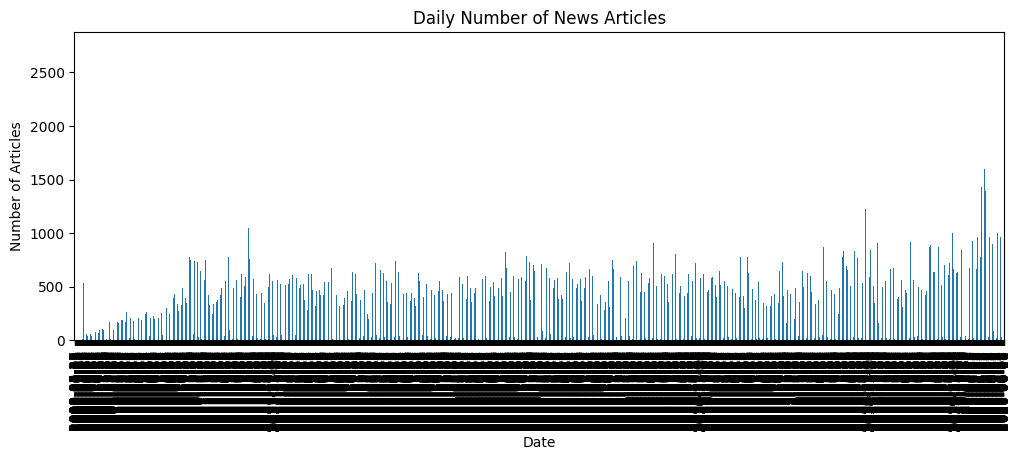

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

# Make sure index is datetime
df.index = pd.to_datetime(df.index, utc=True)

# Count number of articles per day
pd.Series(df.index.date).value_counts().sort_index().plot(kind='bar', figsize=(12,4))

plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.title('Daily Number of News Articles')
plt.show()



D. Top keywords / word cloud

Clean text (lowercase, remove stopwords), get frequent n-grams.
E. Publisher domain parsing (if publisher contains emails)

In [21]:
df['publisher_domain'] = df['publisher'].str.extract(r'@(.+)$')
df['publisher_domain'].value_counts().head(20)


publisher_domain
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net              1
Name: count, dtype: int64

echnical indicators

A. Get OHLCV for each unique stock (or a selected set) — put results in data/prices/.

In [22]:
import yfinance as yf
import os
import pandas as pd

# Make sure the output folder exists
os.makedirs("data/prices", exist_ok=True)

# Define download function
def download_stock(ticker, start="2018-01-01", end="2025-11-21"):
    data = yf.download(ticker, start=start, end=end)
    if data.empty:
        print(f"No data found for ticker: {ticker}")
        return None
    return data

# Get unique tickers from your dataframe
tickers = df['stock'].unique()[:30]  # top 30

# Optional: replace invalid tickers with known real ones if needed
valid_tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']  # example
# tickers = valid_tickers  # Uncomment to test with real tickers

# Loop and download
for t in tickers:
    try:
        p = download_stock(t)
        if p is not None:
            # Save CSV with ticker as filename
            p.to_csv(f"data/prices/{t}.csv")
            print(f"Downloaded and saved: {t}")
    except Exception as e:
        print(f"Error downloading {t}: {e}")


C:\Users\haben\AppData\Local\Temp\ipykernel_5096\592560256.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
C:\Users\haben\AppData\Local\Temp\ipykernel_5096\592560256.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start, end=end)


Downloaded and saved: A


[*********************100%***********************]  1 of 1 completed
C:\Users\haben\AppData\Local\Temp\ipykernel_5096\592560256.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start, end=end)


Downloaded and saved: AA


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AAC']: YFTzMissingError('possibly delisted; no timezone found')
C:\Users\haben\AppData\Local\Temp\ipykernel_5096\592560256.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start, end=end)


...

No data found for ticker: ABDC


[*********************100%***********************]  1 of 1 completed
C:\Users\haben\AppData\Local\Temp\ipykernel_5096\592560256.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start, end=end)


Downloaded and saved: ABEV


[*********************100%***********************]  1 of 1 completed

Downloaded and saved: ABG


B. Indicators — use pandas_ta as it’s pure-Python:

In [28]:
import pandas as pd
from finta import TA

# Example DataFrame
p = pd.DataFrame({
    'Open': [100, 101, 102, 103, 104],
    'High': [105, 106, 107, 108, 109],
    'Low': [95, 96, 97, 98, 99],
    'Close': [102, 103, 104, 105, 106],
    'Volume': [1000, 1100, 1200, 1300, 1400]
})

# SMA50 (even if you have less than 50 rows, it will just return NaN)
p['SMA50'] = TA.SMA(p, 50)

# RSI14
p['RSI14'] = TA.RSI(p, 14)

# MACD
macd_df = TA.MACD(p)
p['MACD'] = macd_df['MACD']
p['MACD_SIGNAL'] = macd_df['SIGNAL']
p['MACD_HIST'] = macd_df['MACD'] - macd_df['SIGNAL']

print(p)


   Open  High  Low  Close  Volume  SMA50  RSI14      MACD  MACD_SIGNAL  \
0   100   105   95    102    1000    NaN    NaN  0.000000     0.000000   
1   101   106   96    103    1100    NaN  100.0  0.022436     0.012464   
2   102   107   97    104    1200    NaN  100.0  0.059598     0.031781   
3   103   108   98    105    1300    NaN  100.0  0.111144     0.058666   
4   104   109   99    106    1400    NaN  100.0  0.176605     0.093750   

   MACD_HIST  
0   0.000000  
1   0.009972  
2   0.027816  
3   0.052478  
4   0.082855  


Visualizations


In [31]:
import pandas as pd
from finta import TA
import matplotlib.pyplot as plt
import os

# Make sure the folder exists
os.makedirs("figures", exist_ok=True)

# Load CSV
p = pd.read_csv("data/prices/AAPL.csv")

# finta requires OHLCV columns
# Your CSV already has 'Open', 'High', 'Low', 'Close', 'Volume', so good to go

# Add a sequential index for plotting
p.index = range(len(p))

# Compute indicators using finta
p['SMA50'] = TA.SMA(p, 50)
p['SMA200'] = TA.SMA(p, 200)
p['RSI14'] = TA.RSI(p, 14)

macd_df = TA.MACD(p)
p['MACD'] = macd_df['MACD']
p['MACD_signal'] = macd_df['SIGNAL']
p['MACD_HIST'] = p['MACD'] - p['MACD_signal']

# ---------------------------
# 1️⃣ Price with SMA overlays
plt.figure(figsize=(12,6))
plt.plot(p.index, p['Close'], label='Close Price', color='blue')
plt.plot(p.index, p['SMA50'], label='SMA50', color='orange')
plt.plot(p.index, p['SMA200'], label='SMA200', color='green')
plt.title('Price with SMA Overlays')
plt.xlabel('Index')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('figures/price_sma.png')
plt.close()

# ---------------------------
# 2️⃣ RSI with overbought/oversold lines
plt.figure(figsize=(12,4))
plt.plot(p.index, p['RSI14'], label='RSI14', color='purple')
plt.axhline(70, color='red', linestyle='--', label='Overbought')
plt.axhline(30, color='green', linestyle='--', label='Oversold')
plt.title('RSI14 Indicator')
plt.xlabel('Index')
plt.ylabel('RSI')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('figures/rsi14.png')
plt.close()

print("Figures saved to 'figures/' folder")


DataError: No numeric types to aggregate